Import Libraries

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



Load Dataset


In [ ]:
df = pd.read_csv(
    '/content/sample_data/fake_job_postings.csv',
    engine='python',
    on_bad_lines='skip'
)


Preprocessing

In [ ]:
df.fillna('', inplace=True)


Combine important text columns

In [ ]:
df['text'] = df['title'] + ' ' + df['location'] + ' ' + df['department'] + ' ' + \
             df['company_profile'] + ' ' + df['description'] + ' ' + \
             df['requirements'] + ' ' + df['benefits']

Features and Target

In [ ]:
X = df['text']
y = df['fraudulent']


Train Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TF-IDF Vectorization

In [ ]:
tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

Train Model

In [ ]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=1000)

Prediction

In [ ]:
y_pred = model.predict(X_test_tfidf)

Evaluation

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9723154362416108

Classification Report:

              precision    recall  f1-score   support

           0       0.97      1.00      0.99      3395
           1       1.00      0.45      0.62       181

    accuracy                           0.97      3576
   macro avg       0.99      0.73      0.80      3576
weighted avg       0.97      0.97      0.97      3576



Confusion Matrix Plot

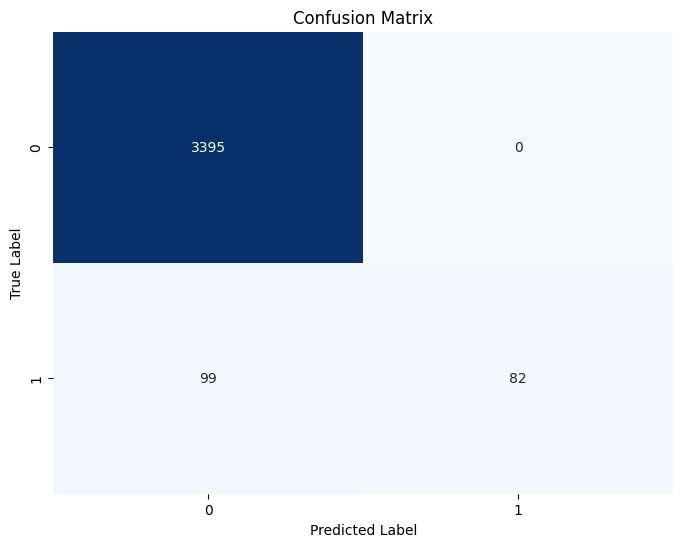

In [ ]:
plt.figure(figsize=(8,6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

Save Model and Vectorizer

In [ ]:
joblib.dump(model, "fake_job_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Model saved as fake_job_model.pkl")
print("Vectorizer saved as tfidf_vectorizer.pkl")

Model saved as fake_job_model.pkl
Vectorizer saved as tfidf_vectorizer.pkl
